In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pathlib import Path

sns.set_style("darkgrid")

In [58]:
path_template = "csv/{}/new/"
syncdir = Path(path_template.format("sync"))
asyncdir = Path(path_template.format("async"))

dfs = []
for d in (asyncdir, syncdir):
    for f in d.glob("*.parquet"):
        print("Loading file:", f)
        parts = f.stem.split("_")
        label_alpha = float(parts[2][1:])
        sample_alpha = float(parts[3][1:])
        
        df = pd.read_csv(f) # TODO: Change your code to save the data as actual parquet files
        df["label_alpha"] = label_alpha
        df["sample_alpha"] = sample_alpha
        df["kind"] = "async" if d == asyncdir else "sync"
        dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df["time"] = pd.to_datetime(df["time"])
df["worker_idx"] = df["worker_idx"].astype(str)
df.head()

Loading file: csv\async\new\test_accuracy_L1.0_S1.0.parquet
Loading file: csv\async\new\test_accuracy_L1.0_S100.0.parquet
Loading file: csv\async\new\test_accuracy_L100.0_S1.0.parquet
Loading file: csv\async\new\test_accuracy_L100.0_S100.0.parquet
Loading file: csv\sync\new\test_accuracy_L1.0_S1.0.parquet
Loading file: csv\sync\new\test_accuracy_L1.0_S100.0.parquet
Loading file: csv\sync\new\test_accuracy_L100.0_S1.0.parquet
Loading file: csv\sync\new\test_accuracy_L100.0_S100.0.parquet


,worker_idx,test_worker_dataset_size,round,test_loss,time,sample_alpha,label_alpha,test_accuracy,timedelta,kind
0,5,57,1,0.215414,2025-07-29 23:46:00.581462,1.0,1.0,0.9626,0.000000,async
1,5,57,2,0.141158,2025-07-29 23:46:10.932147,1.0,1.0,NaN,10.350685,async
2,5,57,3,0.231851,2025-07-29 23:46:21.349151,1.0,1.0,NaN,20.767689,async
3,4,186,1,0.235685,2025-07-29 23:46:26.797805,1.0,1.0,NaN,26.216343,async
4,5,57,4,0.131121,2025-07-29 23:46:32.920580,1.0,1.0,NaN,32.339118,async


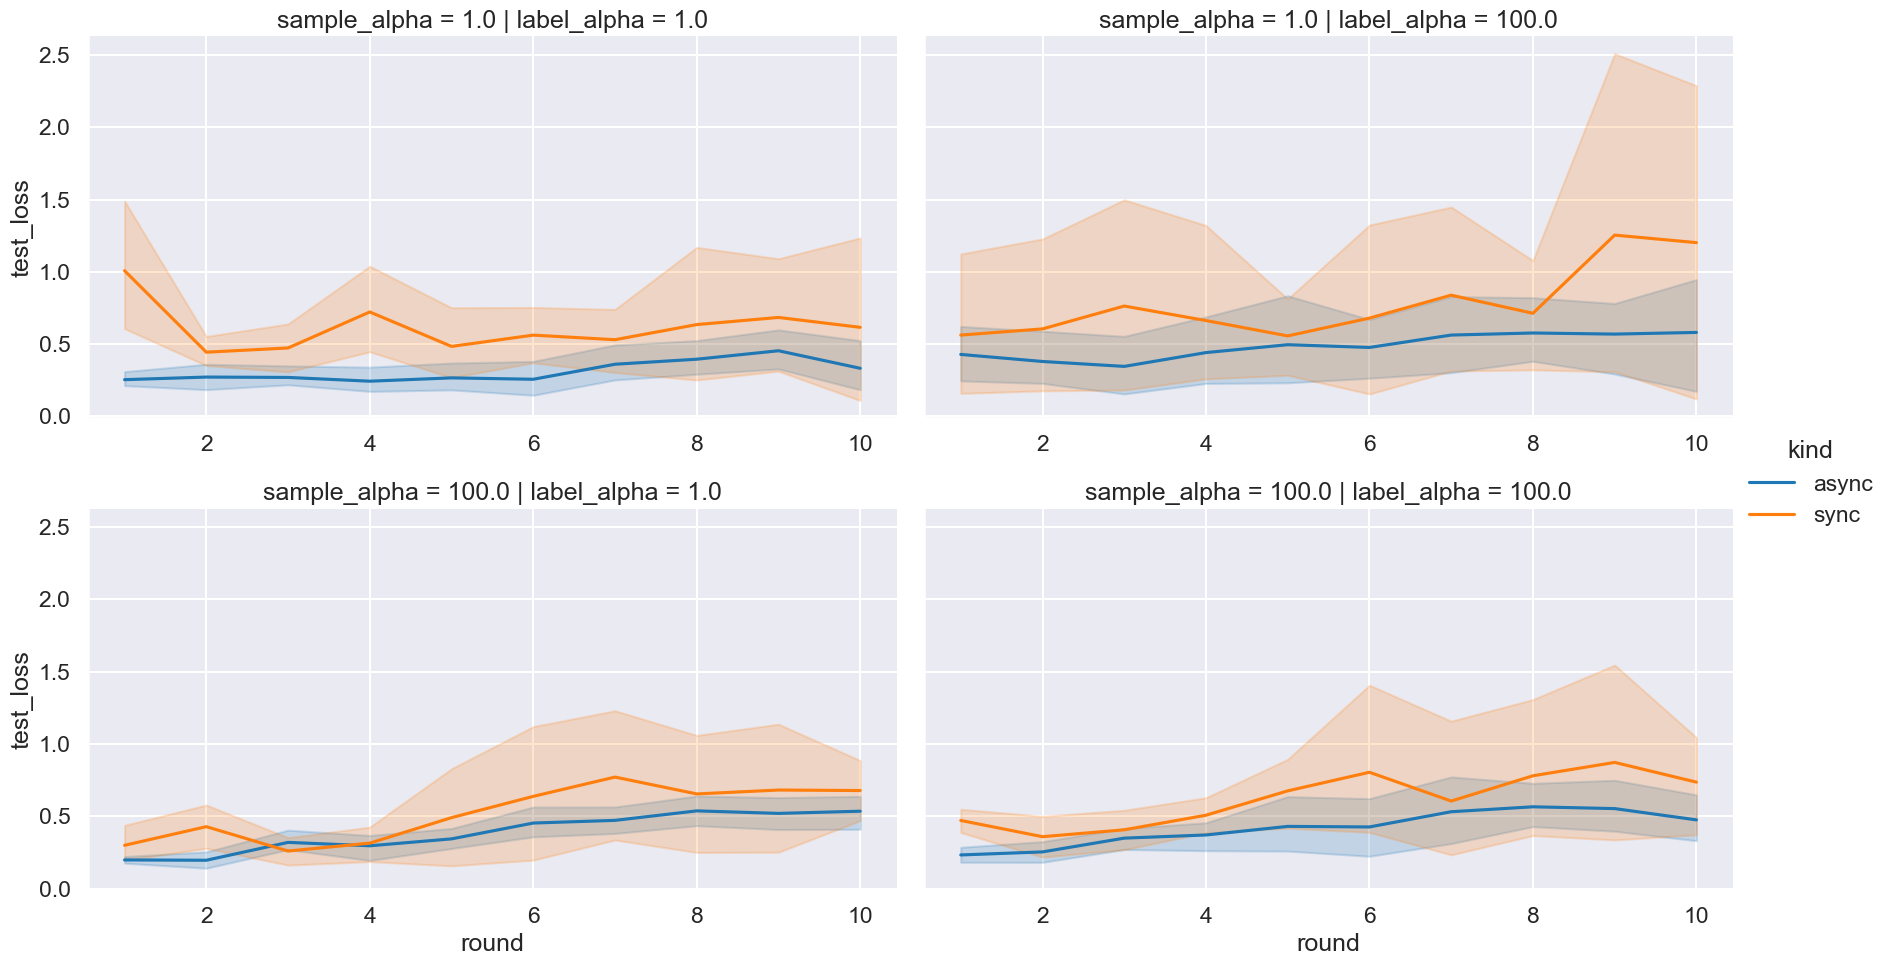

In [59]:
with sns.plotting_context("talk", font_scale=1):
    sns.relplot(
        df,
        kind="line",
        x="round",
        y="test_loss",
        row="sample_alpha",
        col="label_alpha",
        hue="kind",
        facet_kws=dict(sharex=False),
        height=5,
        aspect=16/9,
    )
    plt.savefig("my_figure.png")
    plt.show()

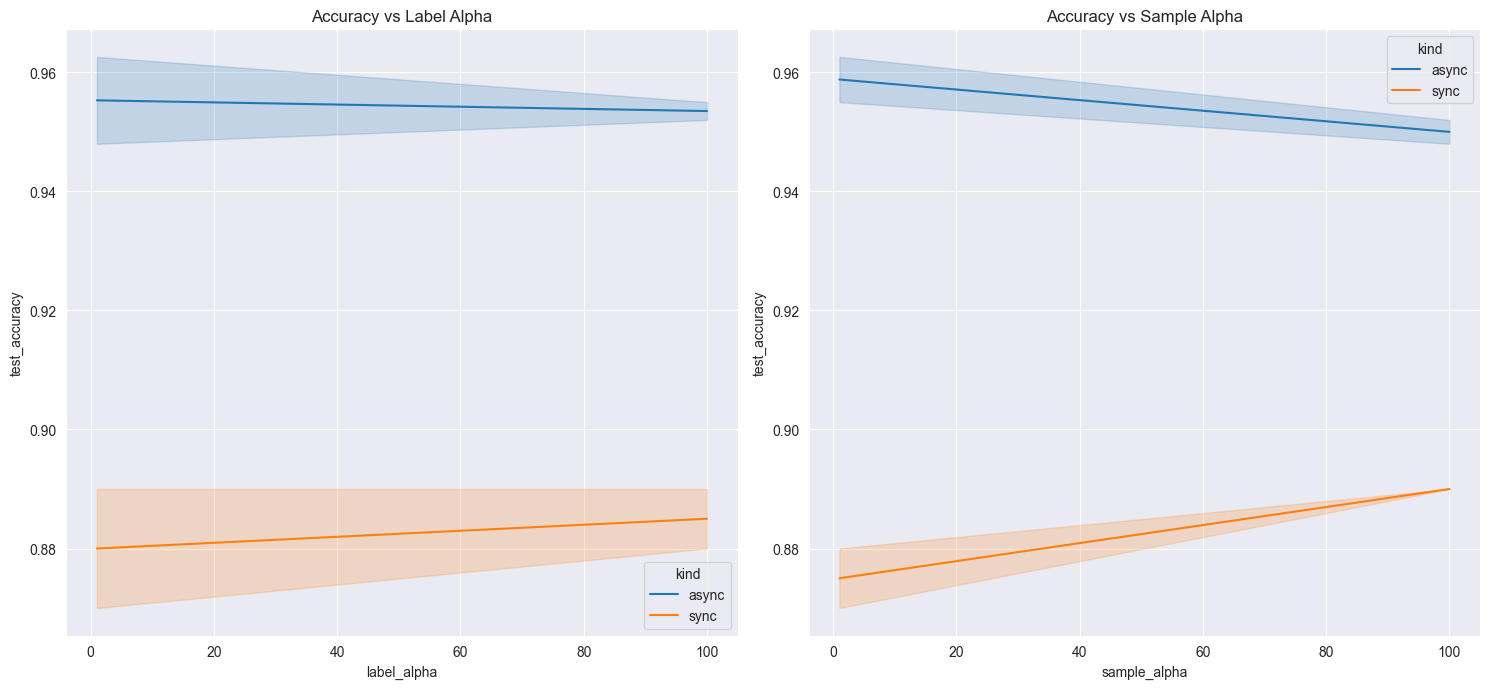

         mean       std  count
kind                          
async  0.9544  0.006173      4
sync   0.8825  0.009574      4


<Figure size 640x480 with 0 Axes>

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract first record from each file group (contains test_accuracy)
accuracy_df = df.groupby(['kind', 'label_alpha', 'sample_alpha']).first().reset_index()

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: Accuracy by scenario type
sns.lineplot(data=accuracy_df, x='label_alpha', y='test_accuracy', hue='kind', ax=axes[0])
axes[0].set_title('Accuracy vs Label Alpha')

# Plot 2: Accuracy vs label_alpha
sns.lineplot(data=accuracy_df, x='sample_alpha', y='test_accuracy', hue='kind', ax=axes[1])
axes[1].set_title('Accuracy vs Sample Alpha')

# Plot 3: Accuracy vs sample_alpha  
# sns.scatterplot(data=accuracy_df, x='sample_alpha', y='test_accuracy', hue='kind', ax=axes[2])
# axes[2].set_title('Accuracy vs Sample Alpha')

plt.tight_layout()
plt.show()
plt.savefig("my_figure2.png")

# Quick stats
print(accuracy_df.groupby('kind')['test_accuracy'].agg(['mean', 'std', 'count']))